# Multiple Correspondence Analysis of Football Transfers

This notebook analyzes the final clustered dataset used in the report. It is an executed, frozen analysis record: the saved outputs are preserved and this notebook is not re-executed during repository preparation.

## Analysis design

Active MCA variables: `player_pos_grouped`, `player_region`, `age_group`, `window`, `is_free`, and `league`. The variables `market_val_amnt`, `transfer_fee_group`, and `cluster` are supplementary and are projected after fitting the MCA.

The notebook reports modality and individual coordinates, contributions, cos² quality of representation, raw and Benzécri-corrected inertia, and supplementary-variable projections. Associations on factorial maps are descriptive and do not imply causation.


In [ ]:
# ============================================================================
# NOTEBOOK COMPLET - ANALYSE EN COMPOSANTES MULTIPLES (ACM)
# Module: Analyse de Données
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from prince import MCA
from scipy.stats import chi2_contingency
import warnings
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)


In [ ]:
# Load the final clustered dataset used by the MCA analysis.
# The saved outputs below were produced from this same artifact.
from pathlib import Path
DATA_PATH = Path("../data/processed/dataset_with_clusters.csv")
df = pd.read_csv(DATA_PATH)


GÉNÉRATION/CHARGEMENT DU DATASET


Saving dataset_with_clusters.csv to dataset_with_clusters (1).csv


In [ ]:

print("\n✓ Dataset chargé avec succès!")
print(f"Shape: {df.shape} (lignes: {df.shape[0]}, colonnes: {df.shape[1]})")
print("\nAperçu du dataset:")
print(df.head(10))

# categorical_cols = ['player_pos_grouped', 'player_region', 'age_group', 'window', 'is_free']
#['league','season', 'cluster','transfer_fee_group']

categorical_cols = ['player_pos_grouped', 'player_region', 'age_group', 'window', 'is_free','league']



X_cat = df[categorical_cols].copy()
X_cat = X_cat.fillna('Manquant').astype(str)


✓ Dataset chargé avec succès!
Shape: (17962, 13) (lignes: 17962, colonnes: 13)

Aperçu du dataset:
  league  season window player_pos_grouped   player_region  \
0    GB1    2009      s           Defender   South America   
1    GB1    2009      s            Forward          Africa   
2    GB1    2009      s         Midfielder  Western Europe   
3    GB1    2009      s            Forward  Western Europe   
4    GB1    2009      s           Defender  Western Europe   
5    GB1    2009      s           Defender  Western Europe   
6    GB1    2009      s         Midfielder  Western Europe   
7    GB1    2009      s           Defender  Eastern Europe   
8    GB1    2009      s            Forward  Western Europe   
9    GB1    2009      s            Forward  Western Europe   

             age_group  is_free  market_val_amnt  transfer_fee_amnt  \
0        Prime (22-25)    False     3.465265e+06       1.880000e+07   
1          Young (≤21)    False     1.600000e+06       4.500000e+06   
2   


PARTIE 1: ANALYSE EN COMPOSANTES MULTIPLES (ACM)

1.1 - Construction du Tableau Disjonctif Complet (TDC)
--------------------------------------------------------------------------------

→ TDC créé: 17962 individus x 24 modalités

1.2 - Ajustement du modèle d'ACM
--------------------------------------------------------------------------------

✓ Nombre d'axes avec λₖ > 1/p (0.1667): 8
✓ Valeurs propres corrigées par Benzécri: 8 axes

→ Graphique 1/4: Éboulis des valeurs propres...


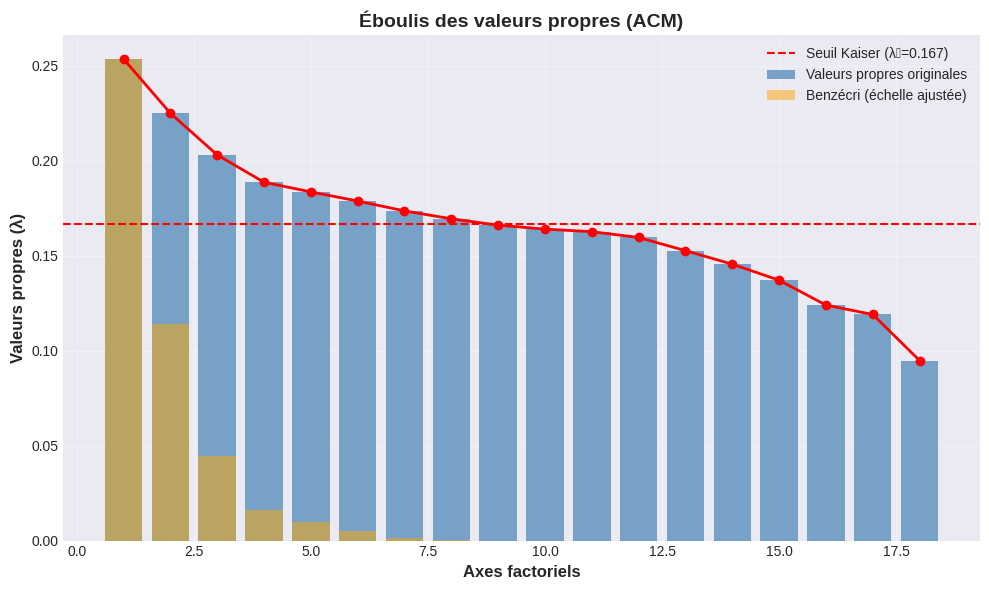

  ✓ Sauvegardé: ACM_1_Eboulis.png

→ Graphique 2/4: Inertie cumulée...


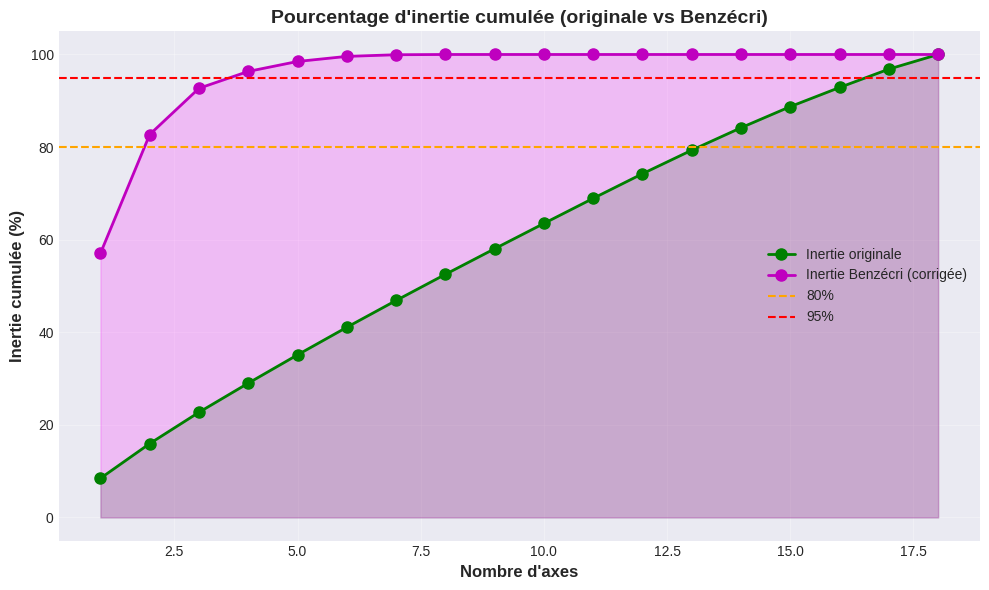

  ✓ Sauvegardé: ACM_2_Inertie.png

→ Graphique 3/4: Nuage des individus...
  → 17962 individus projetés


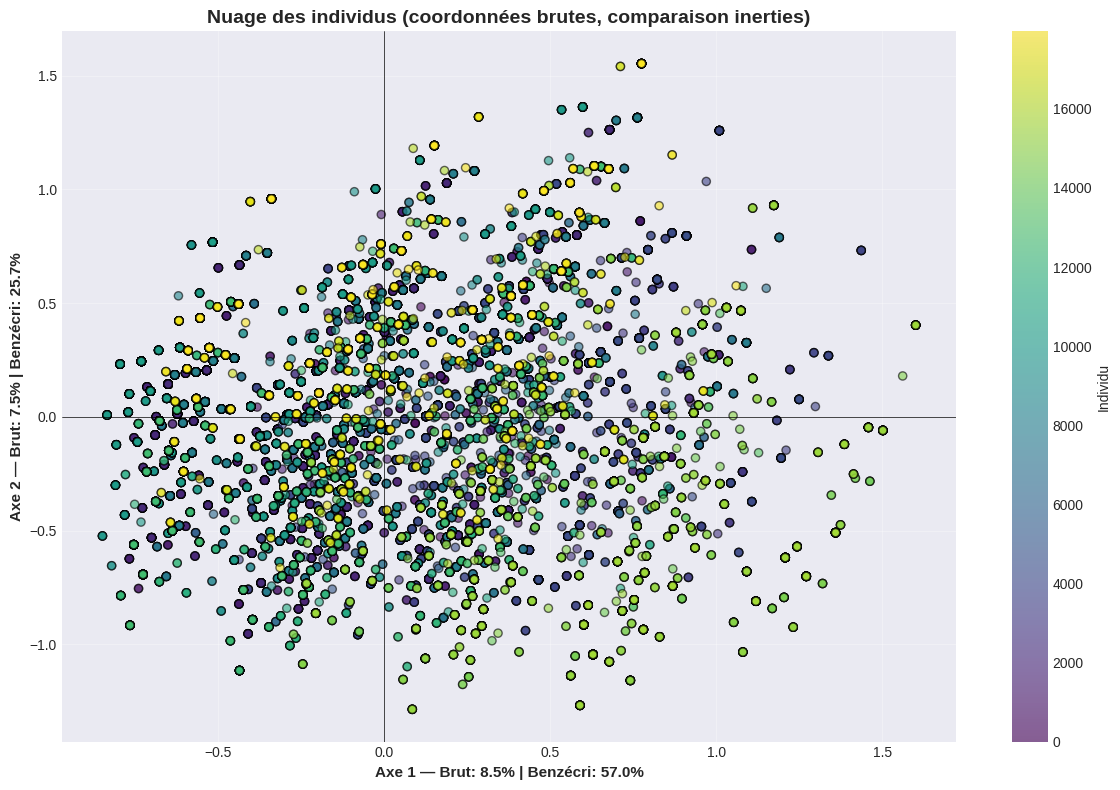

  ✓ Sauvegardé: ACM_3_Individus.png


In [20]:
# ============================================================================
# PARTIE 1: ACM (ANALYSE EN COMPOSANTES MULTIPLES)
# ============================================================================

print("\n" + "="*80)
print("PARTIE 1: ANALYSE EN COMPOSANTES MULTIPLES (ACM)")
print("="*80)

# 1.1 Tableau Disjonctif Complet (TDC)
print("\n1.1 - Construction du Tableau Disjonctif Complet (TDC)")
print("-" * 80)

# Créer TDC manuellement
TDC = pd.get_dummies(X_cat, drop_first=False).astype(int)
# Information sur le TDC
print(f"\n→ TDC créé: {TDC.shape[0]} individus x {TDC.shape[1]} modalités")

# 1.2 Ajustement de l'ACM
print("\n1.2 - Ajustement du modèle d'ACM")
print("-" * 80)

p = len(categorical_cols)
n_axes_mca = TDC.shape[1]-p
inertie_totale_theorique = (TDC.shape[1] - p) / p

mca = MCA(n_components=n_axes_mca, random_state=42)
mca = mca.fit(X_cat)

# Valeurs propres et inerties (brutes, issues directement de la diagonalisation)
eigenvalues_mca = np.array(mca.eigenvalues_)
inertia_pct = (eigenvalues_mca / eigenvalues_mca.sum()) * 100
cumsum_inertia = inertia_pct.cumsum()

# Coordonnées, contributions et qualités de représentation (géométrie brute)
coords_ind_mca = mca.transform(X_cat)
coords_ind_mca.columns = [f'Dim {i+1}' for i in range(coords_ind_mca.shape[1])]
coords_mod_mca = mca.column_coordinates(X_cat)
contrib_mod = mca.column_contributions_ * 100
contrib_ind = mca.row_contributions_ * 100
cos2_mod = mca.column_cosine_similarities(X_cat) * 100
cos2_ind = mca.row_cosine_similarities(X_cat) * 100

cos2_mod_axis1 = cos2_mod.iloc[:, 0]
cos2_mod_axis2 = cos2_mod.iloc[:, 1]
cos2_ind_axis1 = cos2_ind.iloc[:, 0]
cos2_ind_axis2 = cos2_ind.iloc[:, 1]

# Correction de Benzécri (1970) - Formule (1.8): λ̃ₖ = [p/(p-1) * (λₖ - 1/p)]²
# IMPORTANT: Cette correction s'applique UNIQUEMENT aux valeurs propres > 1/p
threshold = 1 / p
lambda_benzmecri = np.zeros_like(eigenvalues_mca)
# Appliquer la correction seulement pour les valeurs propres supérieures au seuil
mask_above_threshold = eigenvalues_mca > threshold
lambda_benzmecri[mask_above_threshold] = ((p / (p - 1)) * (eigenvalues_mca[mask_above_threshold] - threshold)) ** 2
# Calculer l'inertie totale corrigée S_B (formule 1.9)
S_B = lambda_benzmecri.sum()
# Calculer le taux d'inertie pour chaque axe (formule 1.10)
pct_benzecri = (lambda_benzmecri / S_B) * 100 if S_B > 0 else np.zeros_like(lambda_benzmecri)
cumsum_benzecri = pct_benzecri.cumsum()

print(f"\n✓ Nombre d'axes avec λₖ > 1/p ({threshold:.4f}): {mask_above_threshold.sum()}")
print(f"✓ Valeurs propres corrigées par Benzécri: {mask_above_threshold.sum()} axes")

# 2.1 Éboulis des valeurs propres
print("\n→ Graphique 1/4: Éboulis des valeurs propres...")
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(range(1, len(eigenvalues_mca)+1), eigenvalues_mca, alpha=0.7, color='steelblue', label='Valeurs propres originales')
ax1.plot(range(1, len(eigenvalues_mca)+1), eigenvalues_mca, 'ro-', linewidth=2)
ax1.axhline(y=1/p, color='r', linestyle='--', label=f'Seuil Kaiser (λ̄={1/p:.3f})')

# Ajouter les valeurs propres corrigées de Benzécri (échelle alignée)
if lambda_benzmecri.max() > 0:
    benzecri_scaled = lambda_benzmecri * (eigenvalues_mca.max() / lambda_benzmecri.max())
    ax1.bar(range(1, len(lambda_benzmecri)+1), benzecri_scaled, alpha=0.5, color='orange', label='Benzécri (échelle ajustée)')

ax1.set_xlabel('Axes factoriels', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valeurs propres (λ)', fontsize=12, fontweight='bold')
ax1.set_title('Éboulis des valeurs propres (ACM)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ACM_1_Eboulis.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_1_Eboulis.png")

# 2.2 Inertie cumulée
print("\n→ Graphique 2/4: Inertie cumulée...")
fig2, ax2 = plt.subplots(figsize=(10, 6))
# Inertie originale
ax2.plot(range(1, len(cumsum_inertia)+1), cumsum_inertia, 'go-',
         linewidth=2, markersize=8, label='Inertie originale')
ax2.fill_between(range(1, len(cumsum_inertia)+1), cumsum_inertia, alpha=0.2, color='green')

# Inertie corrigée de Benzécri
ax2.plot(range(1, len(cumsum_benzecri)+1), cumsum_benzecri, 'mo-',
         linewidth=2, markersize=8, label='Inertie Benzécri (corrigée)')
ax2.fill_between(range(1, len(cumsum_benzecri)+1), cumsum_benzecri, alpha=0.2, color='magenta')

ax2.axhline(y=80, color='orange', linestyle='--', label='80%')
ax2.axhline(y=95, color='red', linestyle='--', label='95%')
ax2.set_xlabel('Nombre d\'axes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Inertie cumulée (%)', fontsize=12, fontweight='bold')
ax2.set_title('Pourcentage d\'inertie cumulée (originale vs Benzécri)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ACM_2_Inertie.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_2_Inertie.png")

# 2.3 Projection des individus
print("\n→ Graphique 3/4: Nuage des individus...")
fig3, ax3 = plt.subplots(figsize=(12, 8))
coords_plot = coords_ind_mca.iloc[:, :2].dropna()

if not coords_plot.empty:
    x_min, x_max = coords_plot.iloc[:, 0].min(), coords_plot.iloc[:, 0].max()
    y_min, y_max = coords_plot.iloc[:, 1].min(), coords_plot.iloc[:, 1].max()
    pad_x = (x_max - x_min) * 0.05
    pad_y = (y_max - y_min) * 0.05
    # Nuage de TOUS les individus (sans échantillonnage)
    scatter1 = ax3.scatter(coords_plot.iloc[:, 0], coords_plot.iloc[:, 1],
                           c=coords_plot.index, cmap='viridis', s=35, alpha=0.6, edgecolors='black')
    ax3.set_xlim(x_min - pad_x, x_max + pad_x)
    ax3.set_ylim(y_min - pad_y, y_max + pad_y)
    print(f"  → {len(coords_plot)} individus projetés")
else:
    scatter1 = ax3.scatter([], [], c=[], cmap='viridis')
    print("⚠ Aucun individu à projeter (coordonnées absentes)")

ax3.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax3.set_xlabel(f'Axe 1 — Brut: {inertia_pct[0]:.1f}% | Benzécri: {pct_benzecri[0]:.1f}%', fontsize=11, fontweight='bold')
ax3.set_ylabel(f'Axe 2 — Brut: {inertia_pct[1]:.1f}% | Benzécri: {pct_benzecri[1]:.1f}%', fontsize=11, fontweight='bold')
ax3.set_title('Nuage des individus (coordonnées brutes, comparaison inerties)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax3, label='Individu')
plt.tight_layout()
plt.savefig('ACM_3_Individus.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_3_Individus.png")


VISUALISATIONS COMPLÉMENTAIRES - COS² ET CONTRIBUTIONS

→ Graphique complémentaire 1/2: Modalités colorées par cos²...


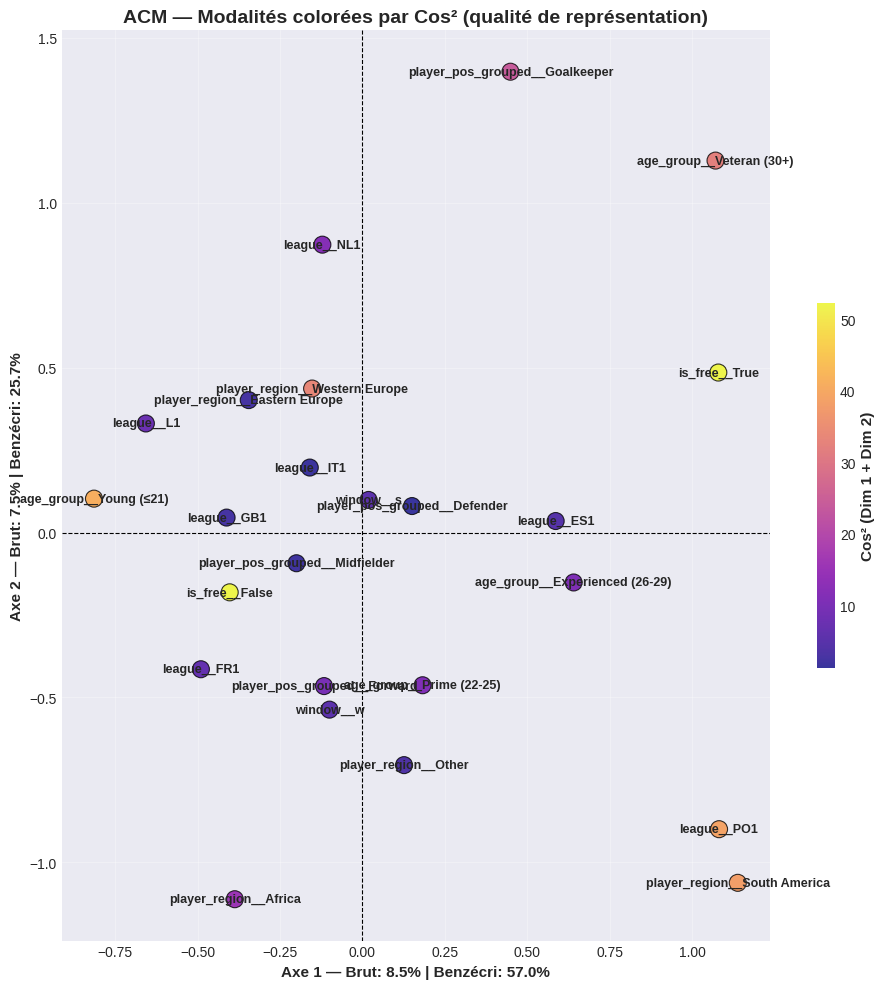

  ✓ Sauvegardé: ACM_Comp1_Modalites_Cos2.png

→ Graphique complémentaire 2/2: Modalités colorées par contribution...


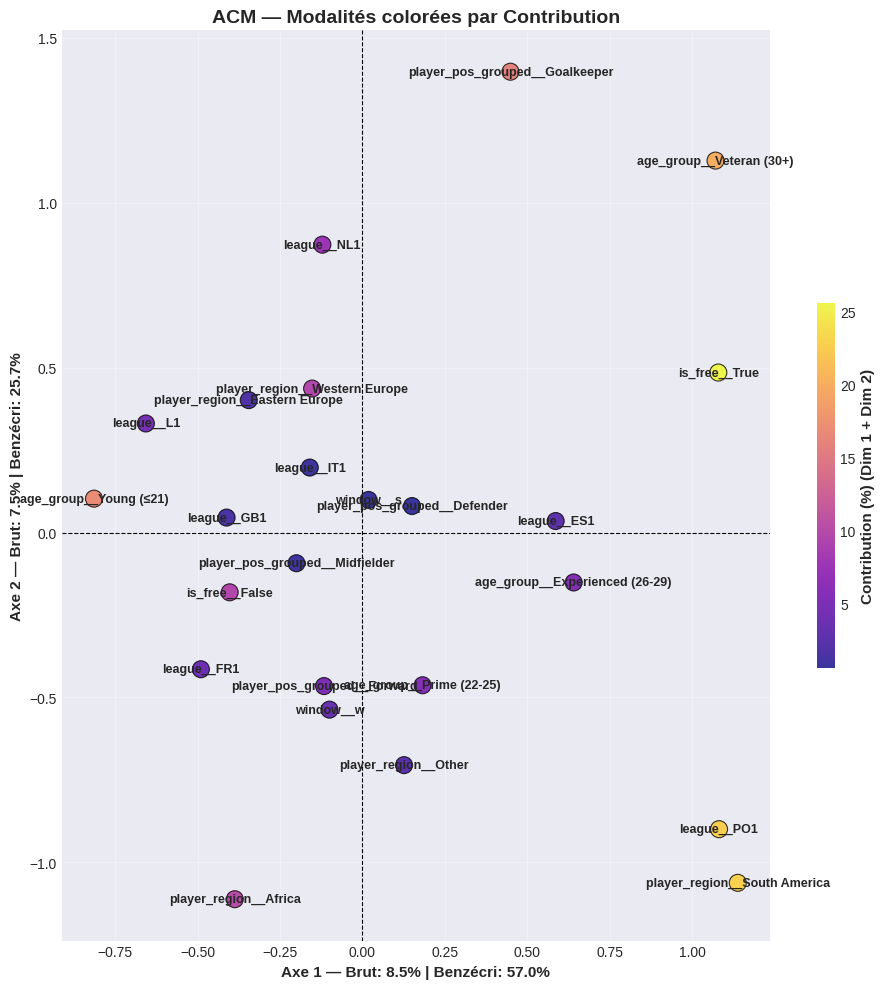

  ✓ Sauvegardé: ACM_Comp2_Modalites_Contrib.png


In [ ]:
# ============================================================================
# VISUALISATIONS COMPLÉMENTAIRES - COS² ET CONTRIBUTIONS SUR LE PLAN
# ============================================================================

print("\n" + "="*80)
print("VISUALISATIONS COMPLÉMENTAIRES - COS² ET CONTRIBUTIONS")
print("="*80)

# Plot 1 — Modalities colored by cos² (quality of representation on the plane)
print("\n→ Graphique complémentaire 1/2: Modalités colorées par cos²...")

# Calculate total cos² on the first two dimensions
cos2_plane = cos2_mod.iloc[:, :2].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(
    coords_mod_mca.iloc[:, 0],
    coords_mod_mca.iloc[:, 1],
    c=cos2_plane,
    cmap="plasma",   # blue → violet → red
    s=150,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8
)

# Add labels for modalities
for idx, i in enumerate(coords_mod_mca.index):
    ax.text(
        coords_mod_mca.iloc[idx, 0],
        coords_mod_mca.iloc[idx, 1],
        i,
        fontsize=9,
        ha="center",
        va="center",
        fontweight='bold'
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel(f'Axe 1 — Brut: {inertia_pct[0]:.1f}% | Benzécri: {pct_benzecri[0]:.1f}%',
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'Axe 2 — Brut: {inertia_pct[1]:.1f}% | Benzécri: {pct_benzecri[1]:.1f}%',
              fontsize=11, fontweight='bold')
ax.set_title("ACM — Modalités colorées par Cos² (qualité de représentation)",
             fontsize=14, fontweight='bold')
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax, label="Cos² (Dim 1 + Dim 2)",shrink=0.4)
cbar.set_label("Cos² (Dim 1 + Dim 2)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('ACM_Comp1_Modalites_Cos2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_Comp1_Modalites_Cos2.png")


# Plot 2 — Modalities colored by contribution
print("\n→ Graphique complémentaire 2/2: Modalités colorées par contribution...")

# Calculate total contribution on the first two dimensions
contrib_plane = contrib_mod.iloc[:, :2].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(
    coords_mod_mca.iloc[:, 0],
    coords_mod_mca.iloc[:, 1],
    c=contrib_plane,
    cmap="plasma",
    s=150,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8
)

# Add labels for modalities
for idx, i in enumerate(coords_mod_mca.index):
    ax.text(
        coords_mod_mca.iloc[idx, 0],
        coords_mod_mca.iloc[idx, 1],
        i,
        fontsize=9,
        ha="center",
        va="center",
        fontweight='bold'
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel(f'Axe 1 — Brut: {inertia_pct[0]:.1f}% | Benzécri: {pct_benzecri[0]:.1f}%',
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'Axe 2 — Brut: {inertia_pct[1]:.1f}% | Benzécri: {pct_benzecri[1]:.1f}%',
              fontsize=11, fontweight='bold')
ax.set_title("ACM — Modalités colorées par Contribution",
             fontsize=14, fontweight='bold')
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax, label="Contribution (%) (Dim 1 + Dim 2)", shrink=0.4)
cbar.set_label("Contribution (%) (Dim 1 + Dim 2)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('ACM_Comp2_Modalites_Contrib.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_Comp2_Modalites_Contrib.png")






# **VISUALISATIONS ADDITIONNELLES (Contributions & Qualité)**



VISUALISATIONS ADDITIONNELLES - CONTRIBUTIONS & QUALITÉ

→ Graphique 5/12: Contributions des modalités (Axe 1)...


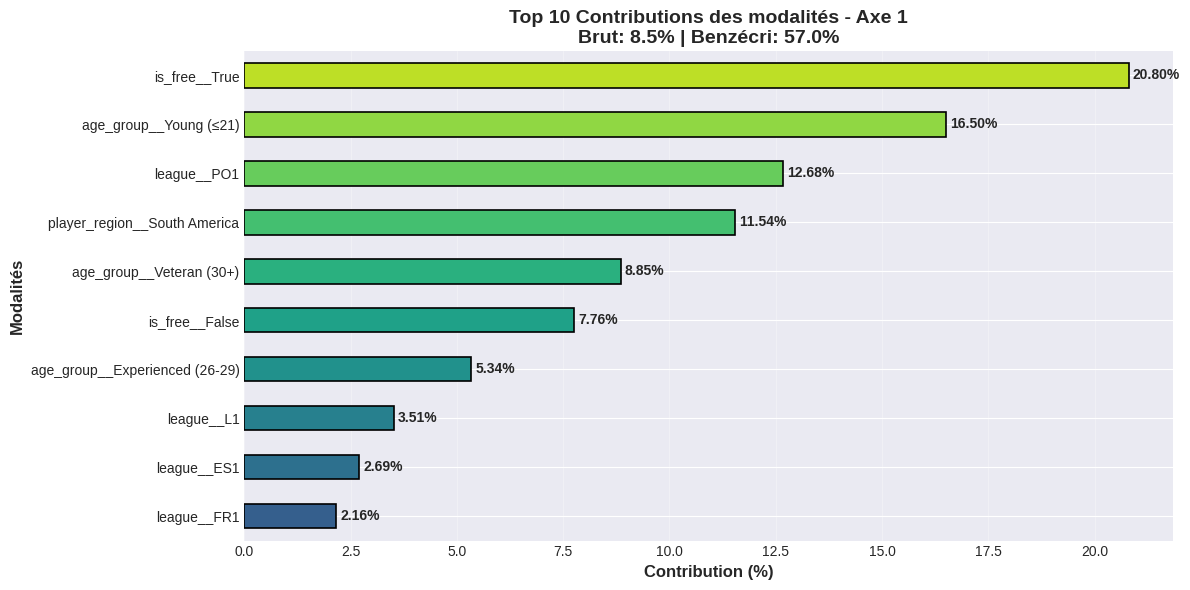

  ✓ Sauvegardé: ACM_5_Contributions_Axe1.png

→ Graphique 6/12: Contributions des modalités (Axe 2)...


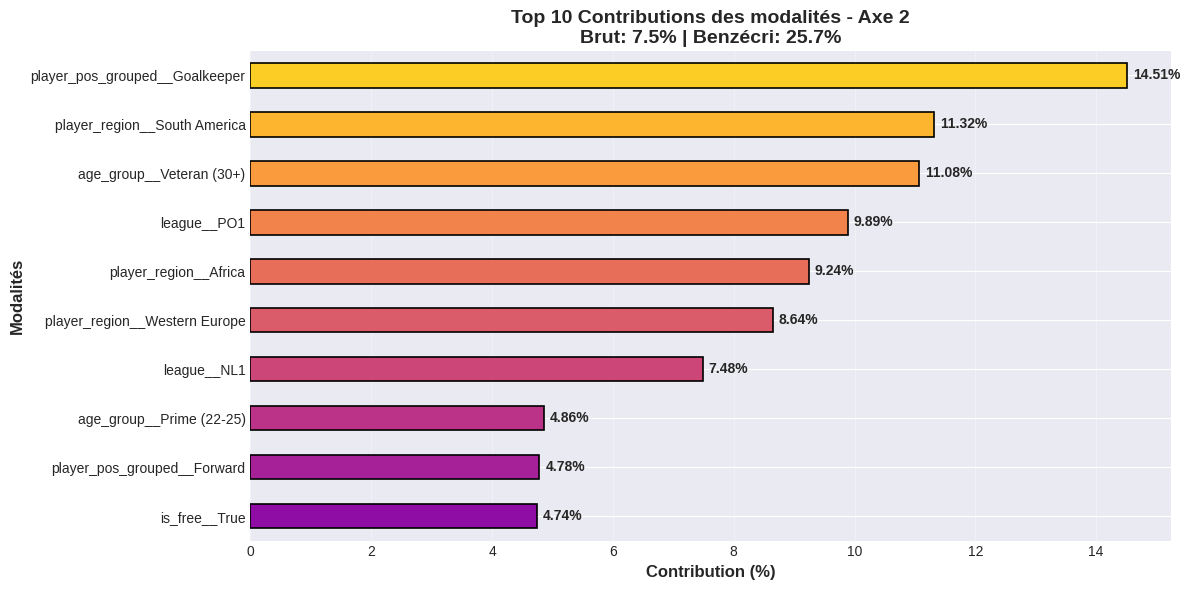

  ✓ Sauvegardé: ACM_6_Contributions_Axe2.png

→ Graphique 7/12: Qualité de représentation des modalités (Axe 1)...


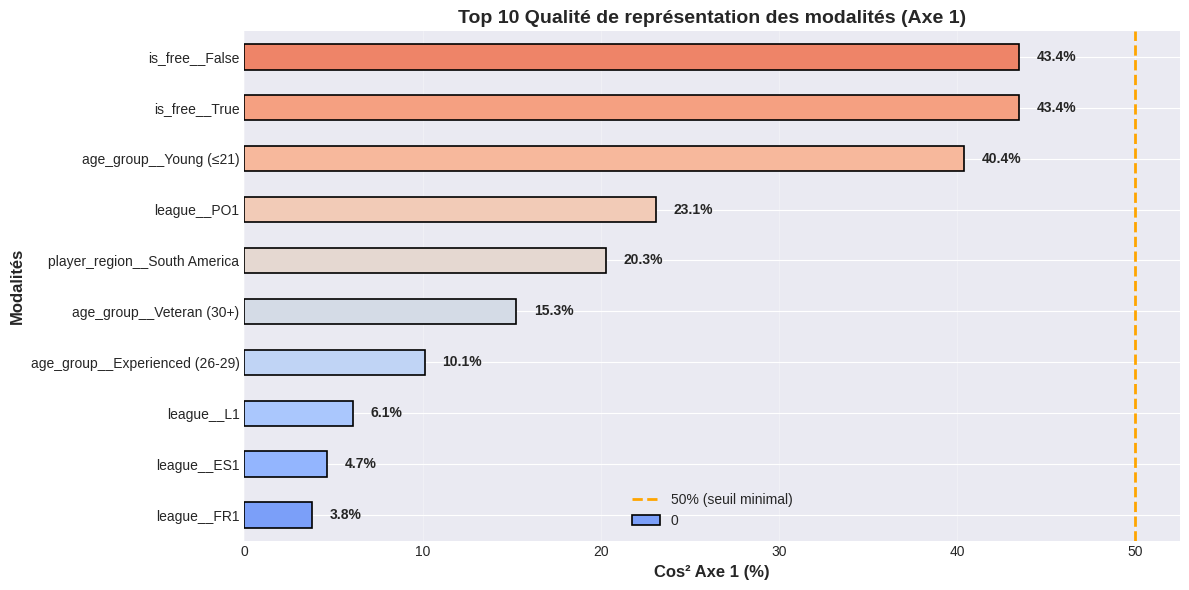

  ✓ Sauvegardé: ACM_7_Qualite_Modalites_Axe1.png

→ Graphique 8/12: Qualité de représentation des modalités (Axe 2)...


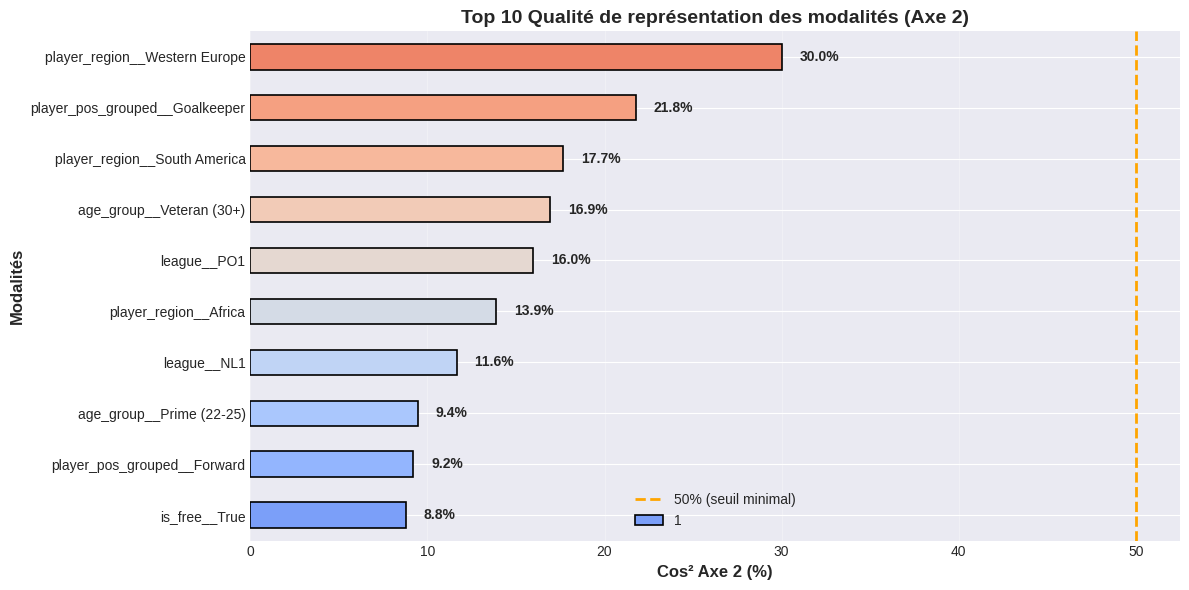

  ✓ Sauvegardé: ACM_8_Qualite_Modalites_Axe2.png

→ Graphique 9/12: Qualité de représentation des individus (Axe 1, top 20)...


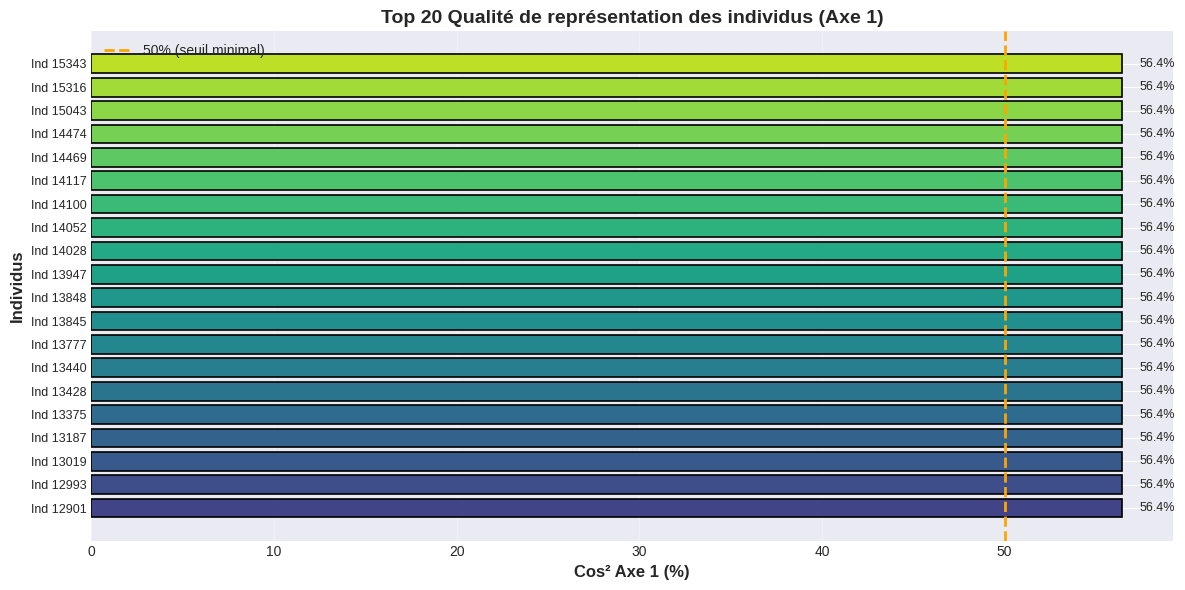

  ✓ Sauvegardé: ACM_9_Qualite_Individus_Axe1.png

→ Graphique 10/12: Qualité de représentation des individus (Axe 2, top 20)...


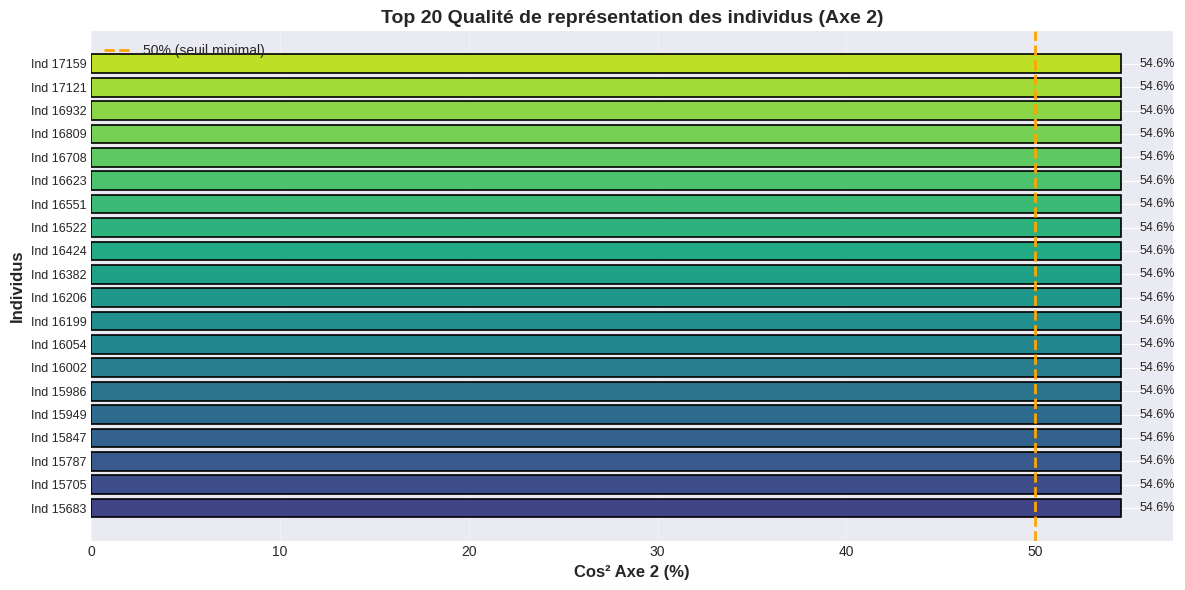

  ✓ Sauvegardé: ACM_10_Qualite_Individus_Axe2.png

→ Graphique 10bis: Distribution des cos² individus (Axe 1)...


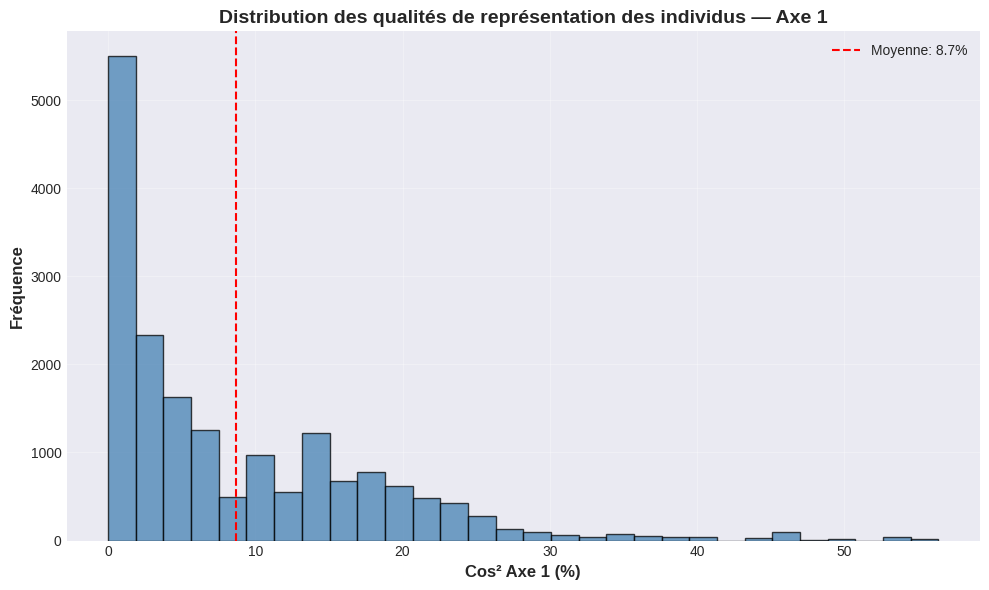

  ✓ Sauvegardé: ACM_10bis_Distribution_Individus_Axe1.png

→ Graphique 10ter: Distribution des cos² individus (Axe 2)...


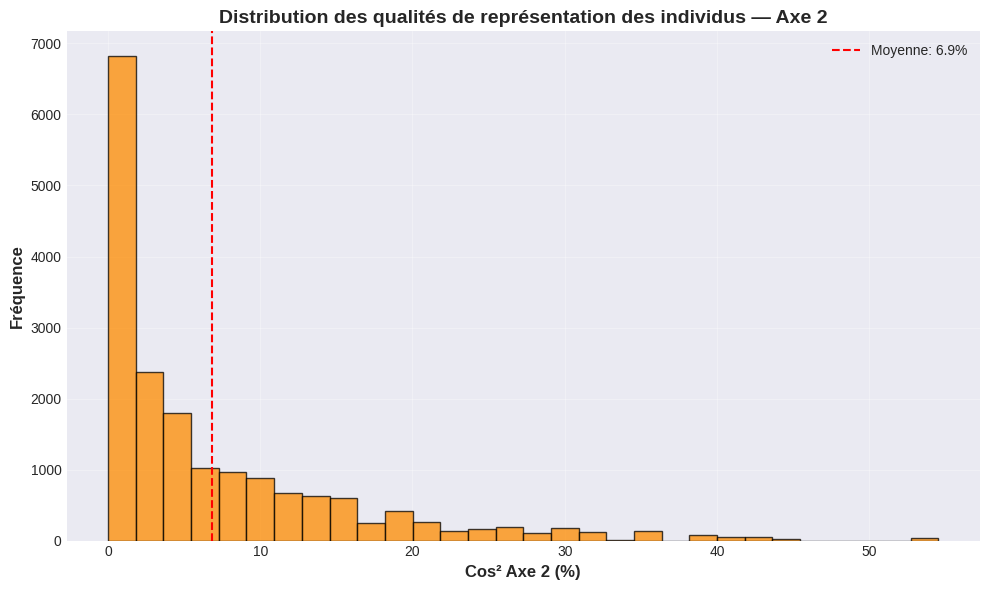

  ✓ Sauvegardé: ACM_10ter_Distribution_Individus_Axe2.png

→ Graphique 11/12: Contribution par variable (Axe 1)...
variable
age_group             31.356682
is_free               28.560335
league                22.928221
player_region         14.217090
player_pos_grouped     2.816412
window                 0.121259
Name: 0, dtype: float64


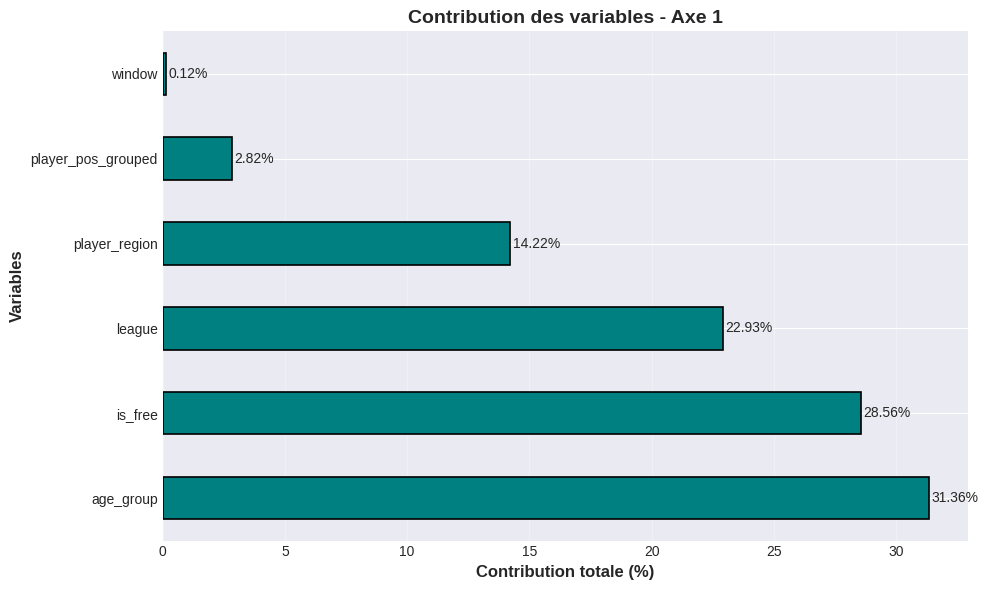

  ✓ Sauvegardé: ACM_11_Variables_Contrib_Axe1.png

→ Graphique 12/12: Contribution par variable (Axe 2)...
variable
player_region         32.649729
league                20.703664
player_pos_grouped    19.629792
age_group             16.563704
is_free                6.513373
window                 3.939738
Name: 1, dtype: float64


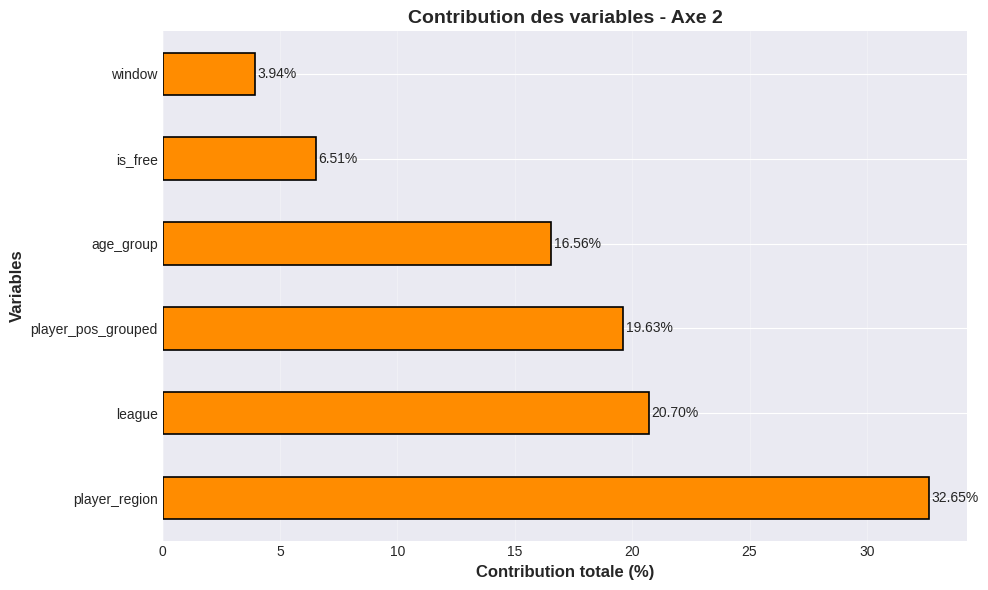

  ✓ Sauvegardé: ACM_12_Variables_Contrib_Axe2.png

→ Graphique 13/12: Qualité de représentation des variables (Axe 1)...


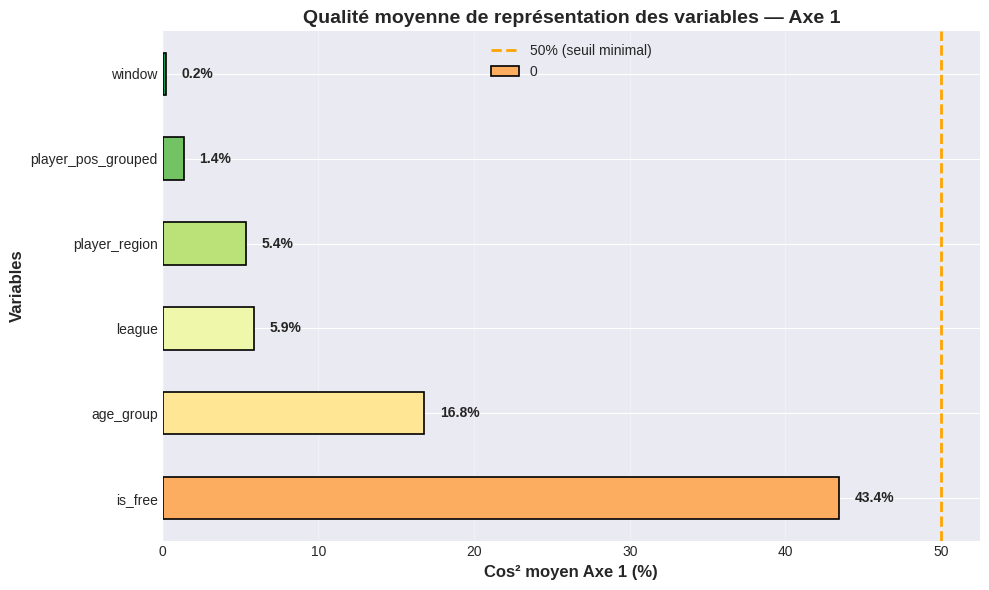

  ✓ Sauvegardé: ACM_13_Qualite_Variables_Axe1.png

→ Graphique 14/12: Qualité de représentation des variables (Axe 2)...


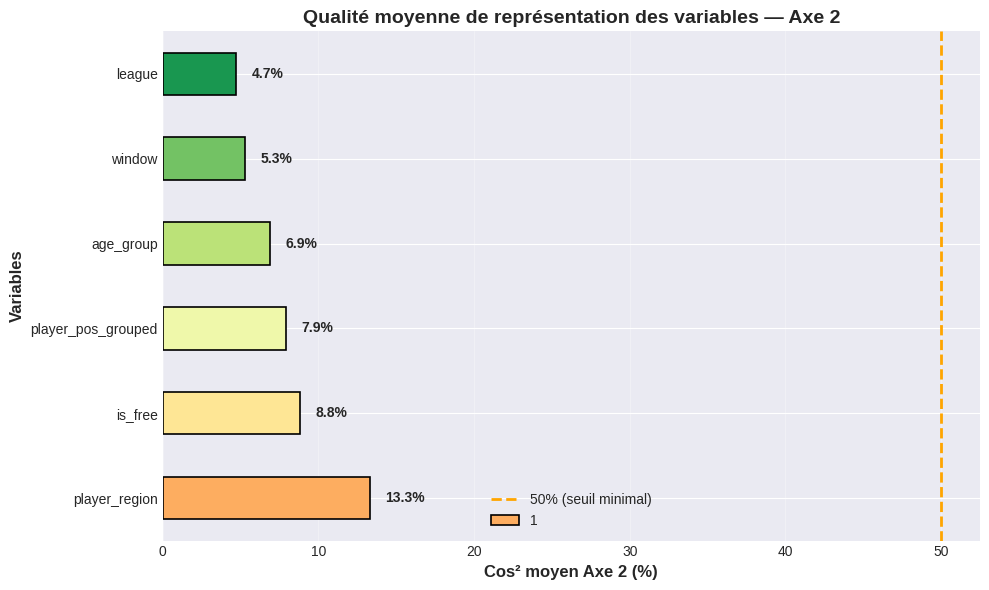

  ✓ Sauvegardé: ACM_14_Qualite_Variables_Axe2.png

✓ Toutes les visualisations additionnelles sauvegardées


In [ ]:


# ============================================================================
# PARTIE 2bis: VISUALISATIONS ADDITIONNELLES (Contributions & Qualité)
# ============================================================================

print("\n" + "="*80)
print("VISUALISATIONS ADDITIONNELLES - CONTRIBUTIONS & QUALITÉ")
print("="*80)

# Préparation des métriques pour les graphiques
cos2_mod_axis1_top = cos2_mod_axis1.nlargest(10).sort_values()
cos2_mod_axis2_top = cos2_mod_axis2.nlargest(10).sort_values()
cos2_ind_axis1_top = cos2_ind_axis1.nlargest(20).sort_values()
cos2_ind_axis2_top = cos2_ind_axis2.nlargest(20).sort_values()

# Regroupement des contributions des modalités par variable
contrib_mod_with_var = contrib_mod.copy()
contrib_mod_with_var['variable'] = contrib_mod_with_var.index.to_series().str.split('__').str[0]
contrib_mod_group_axis1 = contrib_mod_with_var.groupby('variable')[0].sum().sort_values(ascending=False)
contrib_mod_group_axis2 = contrib_mod_with_var.groupby('variable')[1].sum().sort_values(ascending=False)

# 2.5 Contributions des modalités - Axe 1
print("\n→ Graphique 5/12: Contributions des modalités (Axe 1)...")
fig5, ax5 = plt.subplots(figsize=(12, 6))
top_contrib_ax1 = contrib_mod.iloc[:, 0].nlargest(10).sort_values()
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_contrib_ax1)))
top_contrib_ax1.plot(kind='barh', ax=ax5, color=colors, edgecolor='black', linewidth=1.2)
ax5.set_xlabel('Contribution (%)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Modalités', fontsize=12, fontweight='bold')
ax5.set_title(f'Top 10 Contributions des modalités - Axe 1\nBrut: {inertia_pct[0]:.1f}% | Benzécri: {pct_benzecri[0]:.1f}%',
              fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(top_contrib_ax1.values):
    ax5.text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ACM_5_Contributions_Axe1.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_5_Contributions_Axe1.png")

# 2.6 Contributions des modalités - Axe 2
print("\n→ Graphique 6/12: Contributions des modalités (Axe 2)...")
fig6, ax6 = plt.subplots(figsize=(12, 6))
top_contrib_ax2 = contrib_mod.iloc[:, 1].nlargest(10).sort_values()
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_contrib_ax2)))
top_contrib_ax2.plot(kind='barh', ax=ax6, color=colors, edgecolor='black', linewidth=1.2)
ax6.set_xlabel('Contribution (%)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Modalités', fontsize=12, fontweight='bold')
ax6.set_title(f'Top 10 Contributions des modalités - Axe 2\nBrut: {inertia_pct[1]:.1f}% | Benzécri: {pct_benzecri[1]:.1f}%',
              fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(top_contrib_ax2.values):
    ax6.text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ACM_6_Contributions_Axe2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_6_Contributions_Axe2.png")



# 2.7 Qualité de représentation (cos²) des modalités - Axe 1
print("\n→ Graphique 7/12: Qualité de représentation des modalités (Axe 1)...")
fig7, ax7 = plt.subplots(figsize=(12, 6))
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(cos2_mod_axis1_top)))
cos2_mod_axis1_top.plot(kind='barh', ax=ax7, color=colors, edgecolor='black', linewidth=1.2)
ax7.set_xlabel('Cos² Axe 1 (%)', fontsize=12, fontweight='bold')
ax7.set_ylabel('Modalités', fontsize=12, fontweight='bold')
ax7.set_title('Top 10 Qualité de représentation des modalités (Axe 1)', fontsize=14, fontweight='bold')
ax7.grid(True, alpha=0.3, axis='x')
ax7.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% (seuil minimal)')
ax7.legend()
for i, v in enumerate(cos2_mod_axis1_top.values):
    ax7.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ACM_7_Qualite_Modalites_Axe1.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_7_Qualite_Modalites_Axe1.png")

# 2.8 Qualité de représentation (cos²) des modalités - Axe 2
print("\n→ Graphique 8/12: Qualité de représentation des modalités (Axe 2)...")
fig8, ax8 = plt.subplots(figsize=(12, 6))
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(cos2_mod_axis2_top)))
cos2_mod_axis2_top.plot(kind='barh', ax=ax8, color=colors, edgecolor='black', linewidth=1.2)
ax8.set_xlabel('Cos² Axe 2 (%)', fontsize=12, fontweight='bold')
ax8.set_ylabel('Modalités', fontsize=12, fontweight='bold')
ax8.set_title('Top 10 Qualité de représentation des modalités (Axe 2)', fontsize=14, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='x')
ax8.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% (seuil minimal)')
ax8.legend()
for i, v in enumerate(cos2_mod_axis2_top.values):
    ax8.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ACM_8_Qualite_Modalites_Axe2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_8_Qualite_Modalites_Axe2.png")

# 2.9 Qualité de représentation (cos²) des individus - Axe 1 (top 20)
print("\n→ Graphique 9/12: Qualité de représentation des individus (Axe 1, top 20)...")
fig9, ax9 = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cos2_ind_axis1_top)))
top_cos2_ind_labels_axis1 = [f"Ind {idx+1}" for idx in cos2_ind_axis1_top.index]
ax9.barh(range(len(cos2_ind_axis1_top)), cos2_ind_axis1_top.values, color=colors, edgecolor='black', linewidth=1.2)
ax9.set_yticks(range(len(cos2_ind_axis1_top)))
ax9.set_yticklabels(top_cos2_ind_labels_axis1, fontsize=9)
ax9.set_xlabel('Cos² Axe 1 (%)', fontsize=12, fontweight='bold')
ax9.set_ylabel('Individus', fontsize=12, fontweight='bold')
ax9.set_title('Top 20 Qualité de représentation des individus (Axe 1)', fontsize=14, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='x')
ax9.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% (seuil minimal)')
ax9.legend()
for i, v in enumerate(cos2_ind_axis1_top.values):
    ax9.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('ACM_9_Qualite_Individus_Axe1.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_9_Qualite_Individus_Axe1.png")

# 2.10 Qualité de représentation (cos²) des individus - Axe 2 (top 20)
print("\n→ Graphique 10/12: Qualité de représentation des individus (Axe 2, top 20)...")
fig10, ax10 = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cos2_ind_axis2_top)))
top_cos2_ind_labels_axis2 = [f"Ind {idx+1}" for idx in cos2_ind_axis2_top.index]
ax10.barh(range(len(cos2_ind_axis2_top)), cos2_ind_axis2_top.values, color=colors, edgecolor='black', linewidth=1.2)
ax10.set_yticks(range(len(cos2_ind_axis2_top)))
ax10.set_yticklabels(top_cos2_ind_labels_axis2, fontsize=9)
ax10.set_xlabel('Cos² Axe 2 (%)', fontsize=12, fontweight='bold')
ax10.set_ylabel('Individus', fontsize=12, fontweight='bold')
ax10.set_title('Top 20 Qualité de représentation des individus (Axe 2)', fontsize=14, fontweight='bold')
ax10.grid(True, alpha=0.3, axis='x')
ax10.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% (seuil minimal)')
ax10.legend()
for i, v in enumerate(cos2_ind_axis2_top.values):
    ax10.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('ACM_10_Qualite_Individus_Axe2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_10_Qualite_Individus_Axe2.png")

# Distribution des qualités de représentation des individus par axe
print("\n→ Graphique 10bis: Distribution des cos² individus (Axe 1)...")
fig10b, ax10b = plt.subplots(figsize=(10, 6))
ax10b.hist(cos2_ind_axis1, bins=30, color='steelblue', edgecolor='black', alpha=0.75)
ax10b.set_xlabel('Cos² Axe 1 (%)', fontsize=12, fontweight='bold')
ax10b.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax10b.set_title('Distribution des qualités de représentation des individus — Axe 1', fontsize=14, fontweight='bold')
ax10b.axvline(cos2_ind_axis1.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Moyenne: {cos2_ind_axis1.mean():.1f}%")
ax10b.legend()
ax10b.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ACM_10bis_Distribution_Individus_Axe1.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_10bis_Distribution_Individus_Axe1.png")

print("\n→ Graphique 10ter: Distribution des cos² individus (Axe 2)...")
fig10c, ax10c = plt.subplots(figsize=(10, 6))
ax10c.hist(cos2_ind_axis2, bins=30, color='darkorange', edgecolor='black', alpha=0.75)
ax10c.set_xlabel('Cos² Axe 2 (%)', fontsize=12, fontweight='bold')
ax10c.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax10c.set_title('Distribution des qualités de représentation des individus — Axe 2', fontsize=14, fontweight='bold')
ax10c.axvline(cos2_ind_axis2.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Moyenne: {cos2_ind_axis2.mean():.1f}%")
ax10c.legend()
ax10c.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ACM_10ter_Distribution_Individus_Axe2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_10ter_Distribution_Individus_Axe2.png")


print("\n→ Graphique 11/12: Contribution par variable (Axe 1)...")
print(contrib_mod_group_axis1)
fig11, ax11 = plt.subplots(figsize=(10, 6))
contrib_mod_group_axis1.plot(kind='barh', ax=ax11, color='teal', edgecolor='black', linewidth=1.2)
ax11.set_xlabel('Contribution totale (%)', fontsize=12, fontweight='bold')
ax11.set_ylabel('Variables', fontsize=12, fontweight='bold')
ax11.set_title('Contribution des variables - Axe 1', fontsize=14, fontweight='bold')
ax11.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(contrib_mod_group_axis1.values):
    ax11.text(v + 0.1, i, f"{v:.2f}%", va='center', fontsize=10)
plt.tight_layout()
plt.savefig('ACM_11_Variables_Contrib_Axe1.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_11_Variables_Contrib_Axe1.png")

# 2.10 Contributions des modalités groupées par variable - Axe 2
print("\n→ Graphique 12/12: Contribution par variable (Axe 2)...")
print(contrib_mod_group_axis2)
fig12, ax12 = plt.subplots(figsize=(10, 6))
contrib_mod_group_axis2.plot(kind='barh', ax=ax12, color='darkorange', edgecolor='black', linewidth=1.2)
ax12.set_xlabel('Contribution totale (%)', fontsize=12, fontweight='bold')
ax12.set_ylabel('Variables', fontsize=12, fontweight='bold')
ax12.set_title('Contribution des variables - Axe 2', fontsize=14, fontweight='bold')
ax12.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(contrib_mod_group_axis2.values):
    ax12.text(v + 0.1, i, f"{v:.2f}%", va='center', fontsize=10)
plt.tight_layout()
plt.savefig('ACM_12_Variables_Contrib_Axe2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_12_Variables_Contrib_Axe2.png")

# 2.13 Qualité de représentation (cos²) des variables groupées - Axe 1
print("\n→ Graphique 13/12: Qualité de représentation des variables (Axe 1)...")
cos2_mod_with_var = cos2_mod.copy()
cos2_mod_with_var['variable'] = cos2_mod_with_var.index.to_series().str.split('__').str[0]
cos2_var_axis1 = cos2_mod_with_var.groupby('variable')[0].mean().sort_values(ascending=False)
fig13, ax13 = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cos2_var_axis1)))
cos2_var_axis1.plot(kind='barh', ax=ax13, color=colors, edgecolor='black', linewidth=1.2)
ax13.set_xlabel('Cos² moyen Axe 1 (%)', fontsize=12, fontweight='bold')
ax13.set_ylabel('Variables', fontsize=12, fontweight='bold')
ax13.set_title('Qualité moyenne de représentation des variables — Axe 1', fontsize=14, fontweight='bold')
ax13.grid(True, alpha=0.3, axis='x')
ax13.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% (seuil minimal)')
ax13.legend()
for i, v in enumerate(cos2_var_axis1.values):
    ax13.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ACM_13_Qualite_Variables_Axe1.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_13_Qualite_Variables_Axe1.png")

# 2.14 Qualité de représentation (cos²) des variables groupées - Axe 2
print("\n→ Graphique 14/12: Qualité de représentation des variables (Axe 2)...")
cos2_var_axis2 = cos2_mod_with_var.groupby('variable')[1].mean().sort_values(ascending=False)
fig14, ax14 = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cos2_var_axis2)))
cos2_var_axis2.plot(kind='barh', ax=ax14, color=colors, edgecolor='black', linewidth=1.2)
ax14.set_xlabel('Cos² moyen Axe 2 (%)', fontsize=12, fontweight='bold')
ax14.set_ylabel('Variables', fontsize=12, fontweight='bold')
ax14.set_title('Qualité moyenne de représentation des variables — Axe 2', fontsize=14, fontweight='bold')
ax14.grid(True, alpha=0.3, axis='x')
ax14.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% (seuil minimal)')
ax14.legend()
for i, v in enumerate(cos2_var_axis2.values):
    ax14.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ACM_14_Qualite_Variables_Axe2.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_14_Qualite_Variables_Axe2.png")

# Synthèse des visualisations additionnelles
print("\n✓ Toutes les visualisations additionnelles sauvegardées")



# **PROJECTION DES VARIABLES SUPPLÉMENTAIRES**


→ Variables quantitatives supplémentaires: ['market_val_amnt']
→ Variables qualitatives supplémentaires: ['transfer_fee_group']

→ Calcul des corrélations pour les variables quantitatives...
  market_val_amnt: Dim1=-0.192, Dim2=-0.063

→ Calcul des barycentres pour les variables qualitatives...
  transfer_fee_group_Expensive (7M+): (-0.244, -0.122)
  transfer_fee_group_Medium (2-7M): (-0.219, -0.107)
  transfer_fee_group_Free: (0.543, 0.230)
  transfer_fee_group_Cheap (0-2M): (-0.167, -0.047)

→ Graphique: Variables supplémentaires sur le plan factoriel...


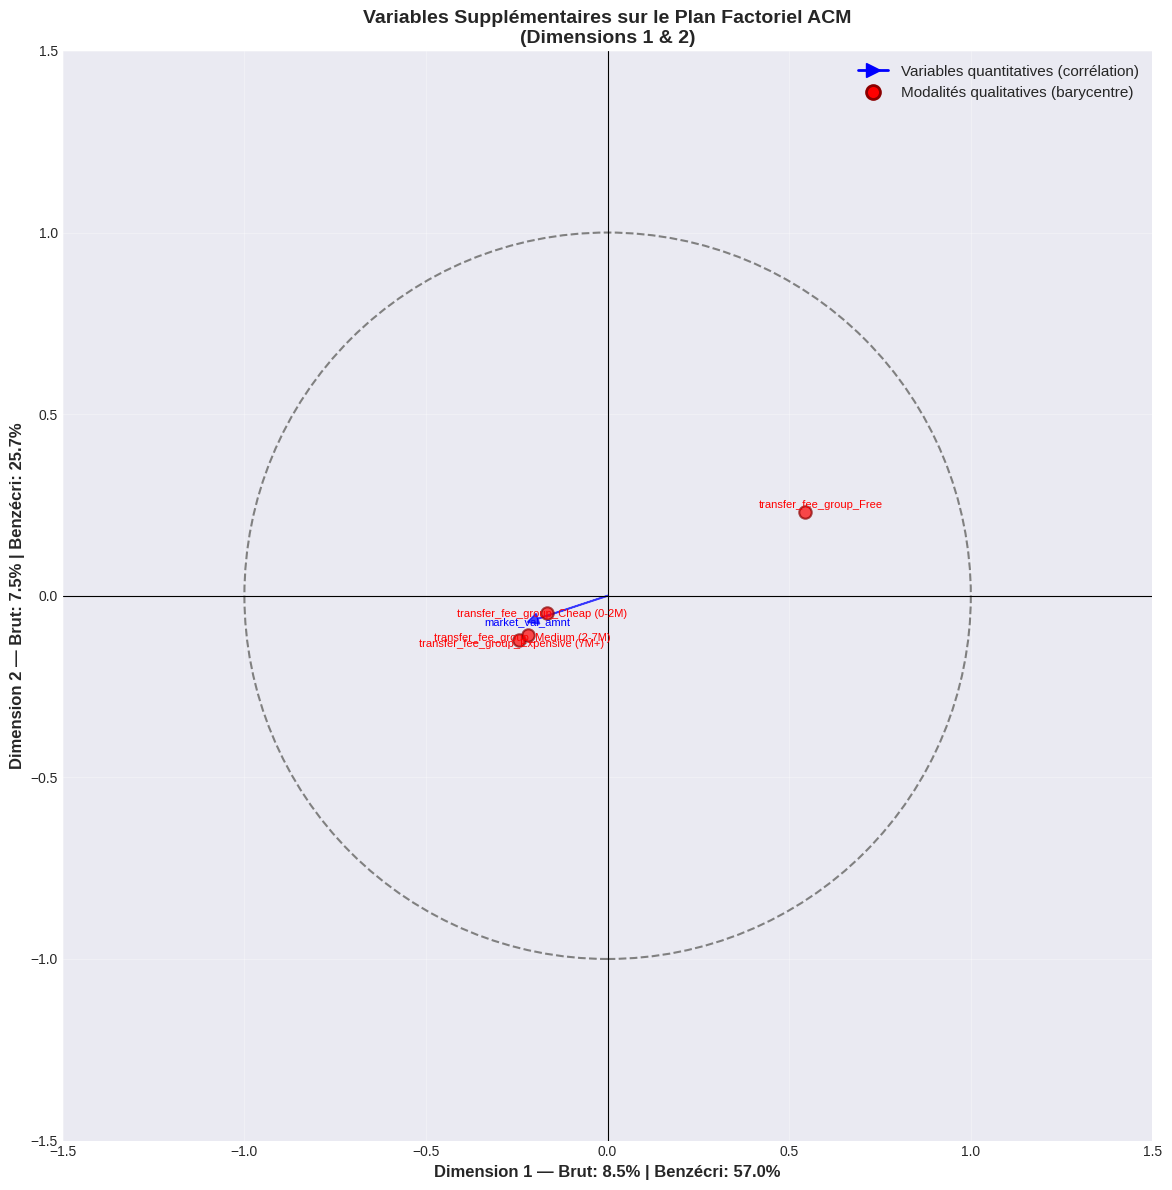

  ✓ Sauvegardé: ACM_Variables_Supplementaires.png


In [ ]:
# ============================================================================
# PARTIE 2 — PROJECTION DES VARIABLES SUPPLÉMENTAIRES
# ============================================================================
quant_vars = ['market_val_amnt']
# Define supplementary variables
# Quantitative supplementary variables (already defined: quant_vars)
df_quant = df[quant_vars].copy()

# Qualitative supplementary variable (using team_class as an example)
qual_supp_vars = ['transfer_fee_group']
df_qual_supp = df[qual_supp_vars].copy()
# Convert categorical columns to string before fillna
for col in df_qual_supp.columns:
    if df_qual_supp[col].dtype.name == 'category':
        df_qual_supp[col] = df_qual_supp[col].astype(str)
df_qual_supp = df_qual_supp.fillna('Unknown').astype(str)

# Use the individual coordinates from the MCA already fitted
row_coords = coords_ind_mca  # This comes from mca.transform(X_cat)

print(f"\n→ Variables quantitatives supplémentaires: {quant_vars}")
print(f"→ Variables qualitatives supplémentaires: {qual_supp_vars}")

# 1. For quantitative variables - calculate correlations with STANDARDIZATION
print("\n→ Calcul des corrélations pour les variables quantitatives...")
correlations = {}
for col in quant_vars:
    # MANDATORY: Standardize the quantitative variable
    X_std = (df_quant[col] - df_quant[col].mean()) / df_quant[col].std()

    # Calculate correlations with first two dimensions
    r_dim1 = np.corrcoef(X_std, row_coords.iloc[:, 0])[0, 1]
    r_dim2 = np.corrcoef(X_std, row_coords.iloc[:, 1])[0, 1]

    correlations[col] = (r_dim1, r_dim2)
    print(f"  {col}: Dim1={r_dim1:.3f}, Dim2={r_dim2:.3f}")

# 2. For qualitative variables - calculate barycenters
print("\n→ Calcul des barycentres pour les variables qualitatives...")
barycenters = {}
for col in qual_supp_vars:
    for category in df_qual_supp[col].unique():
        mask = df_qual_supp[col] == category

        # Barycenter = mean of individual coordinates
        b_dim1 = row_coords.loc[mask, 'Dim 1'].mean()
        b_dim2 = row_coords.loc[mask, 'Dim 2'].mean()

        barycenters[f"{col}_{category}"] = (b_dim1, b_dim2)
        print(f"  {col}_{category}: ({b_dim1:.3f}, {b_dim2:.3f})")

# 3. Plot everything on the same factorial plane
print("\n→ Graphique: Variables supplémentaires sur le plan factoriel...")
fig, ax = plt.subplots(figsize=(12, 12))

# Unit circle (valid for correlation-based projection)
circle = Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.5)
ax.add_patch(circle)

# Arrows for quantitative variables (smaller arrows and lines)
for i, (var, (r1, r2)) in enumerate(correlations.items()):
    ax.arrow(0, 0, r1, r2, head_width=0.03, head_length=0.03,
             fc='blue', ec='blue', linewidth=1.2, alpha=0.7)
    # Text without box, just colored text
    ax.text(r1*1.15, r2*1.15, var, color='blue', fontsize=8,
            ha='center', va='center', fontweight='normal')

# Points for qualitative modalities (smaller points)
for i, (cat, (b1, b2)) in enumerate(barycenters.items()):
    ax.scatter(b1, b2, color='red', s=80, alpha=0.7, marker='o', edgecolor='darkred', linewidth=1.5)
    ax.text(b1*1.08, b2*1.08, cat, color='red', fontsize=8,
        ha='center', va='center', fontweight='normal')

# Axes
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel(f'Dimension 1 — Brut: {inertia_pct[0]:.1f}% | Benzécri: {pct_benzecri[0]:.1f}%',
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'Dimension 2 — Brut: {inertia_pct[1]:.1f}% | Benzécri: {pct_benzecri[1]:.1f}%',
              fontsize=12, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Legend with proxy artists
legend_elements = [
    Line2D([0], [0], color='blue', marker='>', markersize=10,
           label='Variables quantitatives (corrélation)', linestyle='-', linewidth=2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Modalités qualitatives (barycentre)', linestyle='',
           markeredgecolor='darkred', markeredgewidth=2)
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

ax.set_title('Variables Supplémentaires sur le Plan Factoriel ACM\n(Dimensions 1 & 2)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('ACM_Variables_Supplementaires.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_Variables_Supplementaires.png")





# **PROJECTION DE VARIABLE CLUSTER COMME VARIABLE SUPPLÉMENTAIRE**

→ Variable cluster : ['cluster']

→ Calcul des barycentres pour les variables qualitatives...
  cluster_1: (-0.188, 0.005)
  cluster_4: (-0.156, 0.035)
  cluster_2: (-0.216, -0.199)
  cluster_9: (0.376, 0.046)
  cluster_0: (-0.049, -0.032)
  cluster_8: (-0.008, 0.167)
  cluster_6: (-0.324, 0.154)
  cluster_5: (0.073, 0.460)
  cluster_3: (0.579, -0.419)
  cluster_7: (-0.099, 0.401)

→ Graphique: Variable cluster supplémentaire sur le plan factoriel...


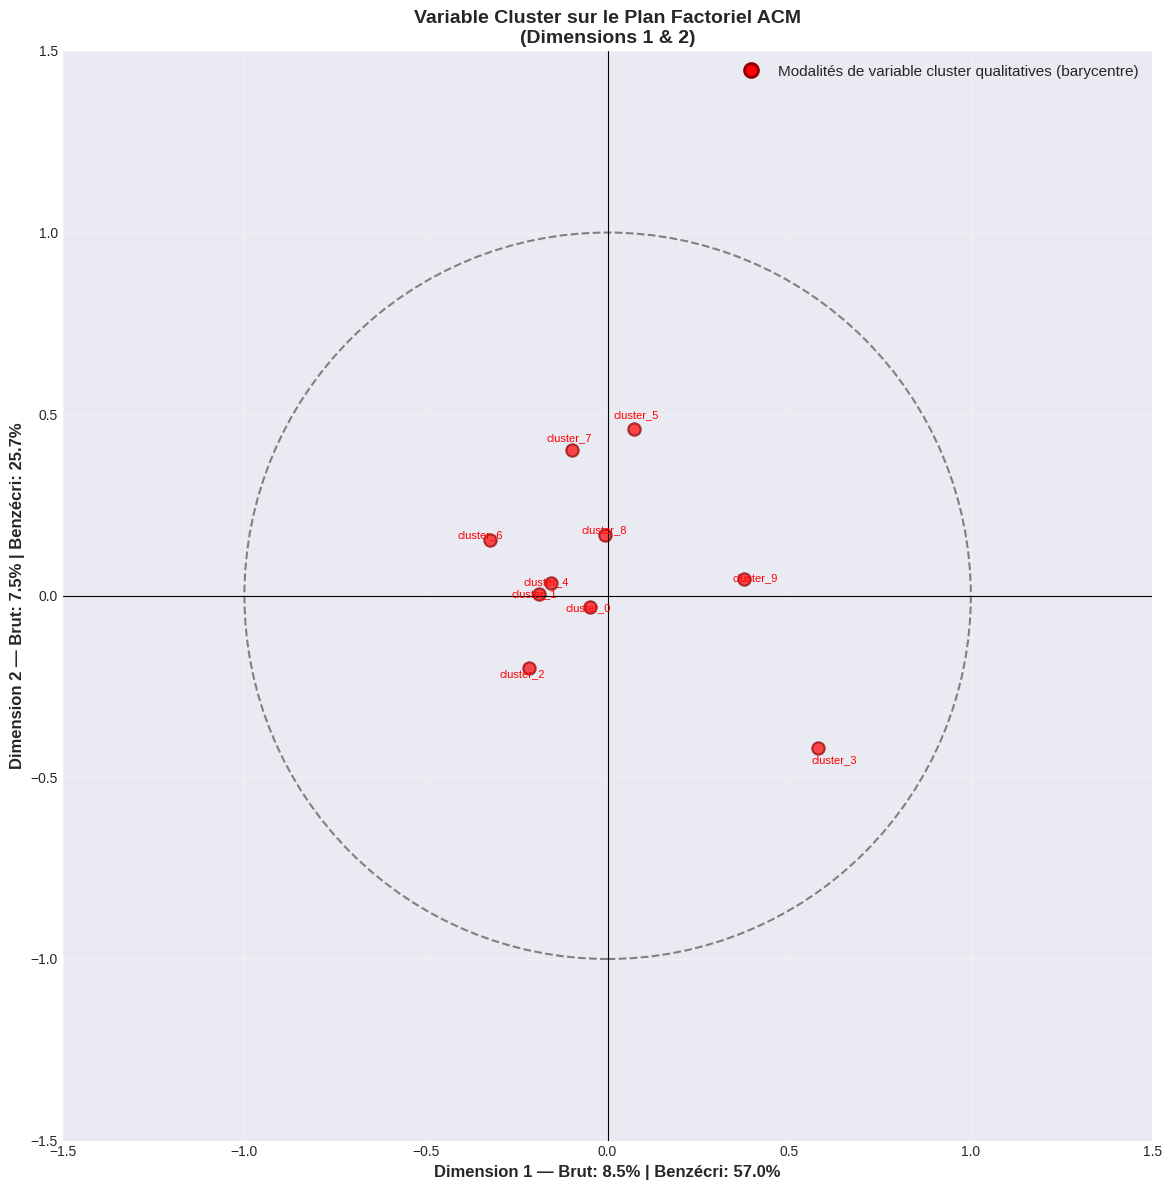

  ✓ Sauvegardé: ACM_Variable_Cluster.png


In [ ]:
# ============================================================================
# PARTIE 2 — PROJECTION DE VARIABLE CLUSTER COMME VARIABLE SUPPLÉMENTAIRE
# ============================================================================

cluster_var = ['cluster']
df_qual_supp = df[cluster_var].copy()
# Convert categorical columns to string before fillna
for col in df_qual_supp.columns:
    if df_qual_supp[col].dtype.name == 'category':
        df_qual_supp[col] = df_qual_supp[col].astype(str)
df_qual_supp = df_qual_supp.fillna('Unknown').astype(str)

# Use the individual coordinates from the MCA already fitted
row_coords = coords_ind_mca  # This comes from mca.transform(X_cat)

print(f"→ Variable cluster : {cluster_var}")


# 2. For qualitative variables - calculate barycenters
print("\n→ Calcul des barycentres pour les variables qualitatives...")
barycenters = {}
for col in cluster_var:
    for category in df_qual_supp[col].unique():
        mask = df_qual_supp[col] == category

        # Barycenter = mean of individual coordinates
        b_dim1 = row_coords.loc[mask, 'Dim 1'].mean()
        b_dim2 = row_coords.loc[mask, 'Dim 2'].mean()

        barycenters[f"{col}_{category}"] = (b_dim1, b_dim2)
        print(f"  {col}_{category}: ({b_dim1:.3f}, {b_dim2:.3f})")

# 3. Plot everything on the same factorial plane
print("\n→ Graphique: Variable cluster supplémentaire sur le plan factoriel...")
fig, ax = plt.subplots(figsize=(12, 12))

# Unit circle (valid for correlation-based projection)
circle = Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.5)
ax.add_patch(circle)

# Arrows for quantitative variables (smaller arrows and lines)
# for i, (var, (r1, r2)) in enumerate(correlations.items()):
#     ax.arrow(0, 0, r1, r2, head_width=0.03, head_length=0.03,
#              fc='blue', ec='blue', linewidth=1.2, alpha=0.7)
#     # Text without box, just colored text
#     ax.text(r1*1.15, r2*1.15, var, color='blue', fontsize=8,
#             ha='center', va='center', fontweight='normal')

# Points for qualitative modalities (smaller points)
for i, (cat, (b1, b2)) in enumerate(barycenters.items()):
    ax.scatter(b1, b2, color='red', s=80, alpha=0.7, marker='o', edgecolor='darkred', linewidth=1.5)
    ax.text(b1*1.08, b2*1.08, cat, color='red', fontsize=8,
        ha='center', va='center', fontweight='normal')

# Axes
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel(f'Dimension 1 — Brut: {inertia_pct[0]:.1f}% | Benzécri: {pct_benzecri[0]:.1f}%',
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'Dimension 2 — Brut: {inertia_pct[1]:.1f}% | Benzécri: {pct_benzecri[1]:.1f}%',
              fontsize=12, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Legend with proxy artists
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Modalités de variable cluster qualitatives (barycentre)', linestyle='',
           markeredgecolor='darkred', markeredgewidth=2)
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

ax.set_title('Variable Cluster sur le Plan Factoriel ACM\n(Dimensions 1 & 2)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('ACM_Variable_Cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Sauvegardé: ACM_Variable_Cluster.png")



In [ ]:

# ============================================================================
# PARTIE 4: EXPORT RÉSULTATS
# ============================================================================

print("\n" + "="*80)
print("PARTIE 8: EXPORT DES RÉSULTATS")
print("="*80)

# Export ACM
acm_export = {
    'Individus': coords_ind_mca.iloc[:, :2],
    'Modalités': coords_mod_mca.iloc[:, :2],
    'Eigenvalues': eigenvalues_mca,
    'Inertia_%': inertia_pct,
    'Benzecri_eigenvalues': lambda_benzmecri,
    'Benzecri_inertia_%': pct_benzecri,
}

print("\n✓ Données ACM exportées pour utilisation ultérieure")
print(f"  - Coordonnées de {len(coords_ind_mca)} individus")
print(f"  - Coordonnées de {len(coords_mod_mca)} modalités")
print(f"  - {len(eigenvalues_mca)} valeurs propres")
print(f"  - Correction de Benzécri incluse")



PARTIE 8: EXPORT DES RÉSULTATS

✓ Données ACM exportées pour utilisation ultérieure
  - Coordonnées de 17962 individus
  - Coordonnées de 24 modalités
  - 18 valeurs propres
  - Correction de Benzécri incluse


In [ ]:
# ============================================================================
# PARTIE 5: INTERPRÉTATION DES RÉSULTATS
# ============================================================================

print("\n" + "="*80)
print("PARTIE 9: INTERPRÉTATION DES RÉSULTATS ACM")
print("="*80)

# Modalités les plus contributives pour les deux premiers axes (géométrie brute)
top_mod_axis1_names = contrib_mod.iloc[:, 0].nlargest(3).index.tolist()
top_mod_axis2_names = contrib_mod.iloc[:, 1].nlargest(3).index.tolist()

# Inertie cumulée corrigée (interprétation uniquement)
benz_cum_axes2 = cumsum_benzecri[min(1, len(cumsum_benzecri)-1)] if len(cumsum_benzecri) > 0 else 0

print("\n📊 ACM - ANALYSE EN COMPOSANTES MULTIPLES:")
print("-" * 80)
print(f"""
✓ Inertie totale: {inertie_totale_theorique:.4f}
  → Les {len(categorical_cols)} variables qualitatives ont {TDC.shape[1]} modalités

✓ Axes retenus: {(eigenvalues_mca > threshold).sum()} axes (λ > λ̄ = {threshold:.4f})
  → Inertie expliquée (originale/brute): {cumsum_inertia[min(2, len(eigenvalues_mca))-1]:.2f}%
  → Inertie expliquée (Benzécri, correction pour interprétation): {benz_cum_axes2:.2f}%

✓ Valeurs propres (2 premiers axes):
  → Axe 1 — Brut: {eigenvalues_mca[0]:.4f} → Benzécri: {lambda_benzmecri[0]:.4f}
  → Axe 2 — Brut: {eigenvalues_mca[1]:.4f} → Benzécri: {lambda_benzmecri[1]:.4f}

✓ Pourcentages d'inertie (2 premiers axes):
  → Axe 1 — Brut: {inertia_pct[0]:.1f}% → Benzécri: {pct_benzecri[0]:.1f}%
  → Axe 2 — Brut: {inertia_pct[1]:.1f}% → Benzécri: {pct_benzecri[1]:.1f}%

✓ Qualité de représentation:
  → Les modalités sont bien représentées sur le plan factoriel principal
  → La proximité entre modalités indique une association
  → NOTA: Axes et coordonnées calculés avec valeurs propres brutes uniquement

✓ Interprétation des axes:
    → Axe 1 (Brut: {inertia_pct[0]:.1f}%):
        Principales contributions: {', '.join(top_mod_axis1_names)}
    → Axe 2 (Brut: {inertia_pct[1]:.1f}%):
        Principales contributions: {', '.join(top_mod_axis2_names)}
""")
print(f"\n📌 Correction de Benzécri (appliquée uniquement aux axes avec λₖ > 1/p = {threshold:.4f}):")
print(f"   Axe 1: {pct_benzecri[0]:.1f}% | Axe 2: {pct_benzecri[1]:.1f}%")
print(f"   Nombre d'axes corrigés: {mask_above_threshold.sum()}")

print("\n" + "="*80)
print("✅ ANALYSE ACM TERMINÉE")
print("="*80)



PARTIE 9: INTERPRÉTATION DES RÉSULTATS ACM

📊 ACM - ANALYSE EN COMPOSANTES MULTIPLES:
--------------------------------------------------------------------------------

✓ Inertie totale: 3.0000
  → Les 6 variables qualitatives ont 24 modalités

✓ Axes retenus: 8 axes (λ > λ̄ = 0.1667)
  → Inertie expliquée (originale/brute): 15.95%
  → Inertie expliquée (Benzécri, correction pour interprétation): 82.72%

✓ Valeurs propres (2 premiers axes):
  → Axe 1 — Brut: 0.2535 → Benzécri: 0.0109
  → Axe 2 — Brut: 0.2249 → Benzécri: 0.0049

✓ Pourcentages d'inertie (2 premiers axes):
  → Axe 1 — Brut: 8.5% → Benzécri: 57.0%
  → Axe 2 — Brut: 7.5% → Benzécri: 25.7%

✓ Qualité de représentation:
  → Les modalités sont bien représentées sur le plan factoriel principal
  → La proximité entre modalités indique une association
  → NOTA: Axes et coordonnées calculés avec valeurs propres brutes uniquement

✓ Interprétation des axes:
    → Axe 1 (Brut: 8.5%):
        Principales contributions: is_free__True

# **ANALYSE ACM TERMINÉE**

In [ ]:
# ============================================================================
# PARTIE 8: ANALYSE ACM TERMINÉE
# ============================================================================
print("✅ ANALYSE ACM TERMINÉE")
print("="*80)
print("\nFichiers générés:")
print("  ✓ ACM_1_Eboulis.png (Éboulis des valeurs propres)")
print("  ✓ ACM_2_Inertie.png (Inertie cumulée)")
print("  ✓ ACM_3_Individus.png (Nuage des individus)")
print("  ✓ ACM_4_Modalites.png (Nuage des modalités)")
print("  ✓ ACM_5_Contributions_Axe1.png (Top contributions modalités Axe 1)")
print("  ✓ ACM_6_Contributions_Axe2.png (Top contributions modalités Axe 2)")
print("  ✓ ACM_7_Qualite_Modalites_Axe1.png (Qualité cos² modalités Axe 1)")
print("  ✓ ACM_8_Qualite_Modalites_Axe2.png (Qualité cos² modalités Axe 2)")
print("  ✓ ACM_9_Qualite_Individus_Axe1.png (Qualité cos² individus Axe 1)")
print("  ✓ ACM_10_Qualite_Individus_Axe2.png (Qualité cos² individus Axe 2)")
print("  ✓ ACM_11_Variables_Contrib_Axe1.png (Contribution par variable Axe 1)")
print("  ✓ ACM_12_Variables_Contrib_Axe2.png (Contribution par variable Axe 2)")
print("\nDonnées disponibles pour analyse ultérieure")
print("="*80 + "\n")

✅ ANALYSE ACM TERMINÉE

Fichiers générés:
  ✓ ACM_1_Eboulis.png (Éboulis des valeurs propres)
  ✓ ACM_2_Inertie.png (Inertie cumulée)
  ✓ ACM_3_Individus.png (Nuage des individus)
  ✓ ACM_4_Modalites.png (Nuage des modalités)
  ✓ ACM_5_Contributions_Axe1.png (Top contributions modalités Axe 1)
  ✓ ACM_6_Contributions_Axe2.png (Top contributions modalités Axe 2)
  ✓ ACM_7_Qualite_Modalites_Axe1.png (Qualité cos² modalités Axe 1)
  ✓ ACM_8_Qualite_Modalites_Axe2.png (Qualité cos² modalités Axe 2)
  ✓ ACM_9_Qualite_Individus_Axe1.png (Qualité cos² individus Axe 1)
  ✓ ACM_10_Qualite_Individus_Axe2.png (Qualité cos² individus Axe 2)
  ✓ ACM_11_Variables_Contrib_Axe1.png (Contribution par variable Axe 1)
  ✓ ACM_12_Variables_Contrib_Axe2.png (Contribution par variable Axe 2)

Données disponibles pour analyse ultérieure

